# KK1 rymduppskjutningar 1957 - 2026

Datan jag använder kommer från GCAT(General Catalog of Artificial Space Objects) som är ihop satt av astrofysikern Jonathan C. Mcdowell, han har dokumenterat varenda raketuppskjutning, banändring och reentry sen 1989 i mer detalj än någon annan offentlig källa och är den forskaren som många mainstream medier går till, som exempel BBC, NYT och Reuters. Jag har primärt använt mig av satcat datasetet som listar alla satelliter uppskjutna från 1957 till 2026, en rad är ett objekt med uppskjutningsdatum, namn, omloppsbana(perigee, apogeem, inklination). Jag använder samt också mig av launch datasetet som listar information om själva raketerna som vilken launch site den har skjutits upp ifrån och som är viktigt för som jag främst använder den till är ifall rocketlaunchen var lyckad.
Viktigt att tilllägga är att satcat är bara jordbane fokuserat, alltså inte inteplanetary missions, ifall du ser en satellite som har lämnat jordens omloppsbana så kommer inte omloppsbana värdena vara användbara.
Det finns också markeringar som kan placeras på (PF, AF, IF) som betyder att det är osäkra värden på perigee, apogee eller inklination.
Jag vill undersöka hur förlitlighet hos raketer har utvecklats över tid, hur uppskjutningstakten har förändrats dom senaste 10 åren och hur stor påverkan spacex har på det nummret. Jag vill också se ifall det finns något samband med att vara en värdsmakt och kunna skjuta upp saker i omloppsbana.



https://planet4589.org/space/gcat/

## Här läser jag in satcat.tsv, launch.tsv och inspekterar strukturen

### 2.1 satcat

In [1]:
import pandas as pd

sat = pd.read_csv("dataset/satcat.tsv", sep="\t", skiprows=[1])
sat.info()
sat.head()

<class 'pandas.DataFrame'>
RangeIndex: 69122 entries, 0 to 69121
Data columns (total 42 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   #JCAT         69122 non-null  str   
 1   Satcat        69122 non-null  object
 2   Launch_Tag    69122 non-null  str   
 3   Piece         69122 non-null  str   
 4   Type          69122 non-null  str   
 5   Name          69122 non-null  str   
 6   PLName        69122 non-null  str   
 7   LDate         69122 non-null  str   
 8   Parent        69122 non-null  str   
 9   SDate         69122 non-null  str   
 10  Primary       69122 non-null  str   
 11  DDate         69122 non-null  str   
 12  Status        69122 non-null  str   
 13  Dest          69122 non-null  str   
 14  Owner         69122 non-null  str   
 15  State         69122 non-null  str   
 16  Manufacturer  69122 non-null  str   
 17  Bus           69122 non-null  str   
 18  Motor         69122 non-null  str   
 19  Mass          6

C:\Users\jacob\AppData\Local\Temp\ipykernel_22140\3959697528.py:3: DtypeWarning: Columns (0: Satcat, 1: Mass, 2: DryMass, 3: TotMass, 4: Length, 5: Diameter, 6: Span, 7: Perigee, 8: Inc) have mixed types. Specify dtype option on import or set low_memory=False.
  sat = pd.read_csv("dataset/satcat.tsv", sep="\t", skiprows=[1])


,#JCAT,Satcat,Launch_Tag,Piece,Type,Name,PLName,LDate,Parent,SDate,...,ODate,Perigee,PF,Apogee,AF,Inc,IF,OpOrbit,OQUAL,AltNames
0,S00001,1,1957 ALP,1957 ALP 1,R2,8K71PS No. M1-10 Stage 2,8K71A M1-10 (M1-1PS),1957 Oct 4,-,1957 Oct 4 1933,...,1957 Oct 4,214,,938,,65.1,,LLEO/I,-,-
1,S00002,2,1957 ALP,1957 ALP 2,P,1-y ISZ,PS-1,1957 Oct 4,S00001,1957 Oct 4 1933,...,1957 Oct 4,214,,938,,65.1,,LLEO/I,-,":RE,:RC"
2,S00003,3,1957 BET,1957 BET 1,P A,2-y ISZ,PS-2,1957 Nov 3,A00002,1957 Nov 3 0235,...,1957 Nov 3,211,,1659,,65.33,,LEO/I,-,":RE,:RC"
3,S00004,4,1958 ALP,1958 ALP,P A,Explorer I,Explorer 1,1958 Feb 1,A00004,1958 Feb 1 0355,...,1958 Feb 1,359,,2542,,33.18,,LEO/I,-,":UA,:UB,DEAL I:IA"
4,S00005,5,1958 BET,1958 BET 2,P,Vanguard I,Vanguard Test Satellite H,1958 Mar 17,S00016,1958 Mar 17 1224,...,1959 May 23,657,,3935,,34.25,,MEO,-,":UA,:VA"


#### Vad jag observerar från satcat

1. Alla kolumner från satcat är antingen en str eller object, inga numeriska värden. Det betyder att att mass, perigee, apogee, inc är text trots att dom innehåller nummer.

2. Datumkolumnerna (LDate, SDate, DDate, ODate) är på formatet "1959 Jan  2", alltså mänskligt läsbart men inte ISO. Så jag behöver `pd.to_datetime()` så jag kan göra den till rätt format när jag ska sortera och plotta över tid.


### 2.2 launch

In [2]:
launch = pd.read_csv("dataset/launch.tsv", sep="\t", skiprows=[1])
launch.info()
launch.head()

<class 'pandas.DataFrame'>
RangeIndex: 75831 entries, 0 to 75830
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   #Launch_Tag  75831 non-null  str    
 1   Launch_JD    75831 non-null  float64
 2   Launch_Date  75831 non-null  str    
 3   LV_Type      75831 non-null  str    
 4   Variant      75831 non-null  str    
 5   Flight_ID    75831 non-null  str    
 6   Flight       75831 non-null  str    
 7   Mission      75831 non-null  str    
 8   FlightCode   75831 non-null  str    
 9   Platform     75831 non-null  str    
 10  Launch_Site  75831 non-null  str    
 11  Launch_Pad   75831 non-null  str    
 12  Ascent_Site  75831 non-null  str    
 13  Ascent_Pad   75831 non-null  str    
 14  Apogee       75831 non-null  str    
 15  Apoflag      75831 non-null  str    
 16  Range        75831 non-null  str    
 17  RangeFlag    75831 non-null  str    
 18  Dest         75831 non-null  str    
 19  OrbPay       75

,#Launch_Tag,Launch_JD,Launch_Date,LV_Type,Variant,Flight_ID,Flight,Mission,FlightCode,Platform,...,Dest,OrbPay,Agency,LaunchCode,FailCode,Group,Category,LTCite,Cite,Notes
0,1942-A01,2430523.95,1942 Jun 13 1052,A-4,-,2,-,-,-,-,...,-,0.0,WEHR,MF,U,-,Test,TTaylor,-,-
1,1942-A02,2430587.97,1942 Aug 16 1115,A-4,-,3,-,-,-,-,...,-,0.0,WEHR,MF,U,-,Test,Stuhlinger,RocketTeam,-
2,1942-S01,2430636.12,1942 Oct 3 1458,A-4,-,4,-,-,-,-,...,-,0.0,WEHR,MS,-,-,Test,Stuhlinger,AE1961A,-
3,1942-A03,2430653.50,1942 Oct 21,A-4,-,5,-,-,-,-,...,-,0.0,WEHR,MS,-,-,Test,AE1961A,-,-
4,1942-M01,2430672.50,1942 Nov 9,A-4,-,6,-,-,-,-,...,-,0.0,WEHR,MS,-,-,Test,AE1961A,-,-


#### Vad jag observerar från launch

1. launch har 75831 entries och satcat har 69122 entries trotts att jag förvänta mig att att satcat borde innehålla mer. Det är en skillnad med 6 709 rader och speglar troligen misslyckade och suborbitala uppskjutningar samt att den innehåller uppskjutningar från hela vägen bak till 1942 och innehåller missil tester, det är bra att se allt det här nu för jag vill filtrera ut missiler och suborbitala uppskjutningar för dom är inte relevanta för min analys och det har inte pålitlig information ifall dom är lyckade eller inte som skulle lägga osäkerhet på min fråga om pålitlighet om raketer.

2. Jag ser också att det launch har LaunchCode, Failcode, Dest och Agency som är bra för det behöver jag för att kunna svara på mina frågor.

## 3. Datatvätt

I det här avsnittet rensar och normaliserar jag datan innan jag använder den i analysen. Första steget är att titta närmare på `LaunchCode` och `FailCode` i launch-tabellen, dessa två kolumner styr min senare definition av en "lyckad uppskjutning", så jag behöver veta vilka värden som faktiskt förekommer innan jag bestämmer hur jag kategoriserar dem.

In [3]:
# Använder display.max_rows för att visa alla raders value_counts och inte bara de 10 vanligaste också så kan se alla codes som finns i datasetet

with pd.option_context("display.max_rows", None):
    print(launch["LaunchCode"].value_counts())
    print(launch["FailCode"].value_counts())

LaunchCode
SS      39963
MS      12965
SU       8740
OS       6512
AS       2162
MU       1450
MF       1134
SF        832
AU        450
OF        425
YS        285
DS        225
TS        164
YF        136
OF40       67
AF         63
RS         60
HS         35
TF         32
OS75       19
OE         16
ME         14
TU         12
RF         11
XS         11
HF          9
!           7
OF25        5
OS80        5
OF50        4
OS85        3
OF20        2
TE          1
OS66        1
OF70        1
OS60        1
OS90        1
OF45        1
OF60        1
OF30        1
SE          1
OF44        1
OS89        1
OS65        1
OS95        1
Name: count, dtype: int64
FailCode
-         73068
U          2021
S1          125
S2P          64
S1P          61
S1G          42
S2           42
S3P          33
S2G          30
FF           24
S4I          23
S2I          21
PE           20
S1S          16
S2R          14
S3G          13
S3I          13
S1I          11
S2U          10
S3           10
S0P 

### 3.1 LaunchCode definiera lyckad vs misslyckad


`LaunchCode` är en 2 bokstavskod där varje bokstav har en specifik betydelse.

**Första bokstaven, typ av uppskjutning:**
- `O` - Orbital (försök att nå omloppsbana), det är detta jag vill analysera
- `M` - Military missile (militär ballistisk missiltest)
- `S` - Suborbital rocket other than missile (icke-militär suborbital raket)
- `A` - Atmospheric rocket (atmosfärisk höghöjdsraket)
- `T` - Test rocket
- `D` - Deep space mission
- `H` - High altitude sounding rocket (höghöjds-sondraket)
- `R` - Reentry test
- `X` - Launch from world other than Earth (uppskjutning från annan himlakropp än jorden)
- `Y` - Suborbital spaceplane with human crew (bemannad suborbital rymdplansflygning)

**Andra bokstaven - utfall:**
- `S` - Success (propulsiv framgång, även om payloaden inte returnerade data)
- `F` - Fail
- `U` - Unknown (utfall okänt)
- `E` - Pad explosion, raketen exploderade på rampen *innan* uppskjutning, alltså ingen flygning skedde alls. Inkluderad i listan för fullständighet.

Vissa orbitala koder har också en siffra i slutet som anger en success score från 00 till 99 (procent), inte fas av flygningen. Exempel:
- `OF25` (0.25) - payload misslyckades att separera eller skadades fatalt av bärraketen
- `OF40` (0.40) - "orbit but not a usable one"
- `OS75` (0.75) - bana användbar men inte nominell
- `OS85` (0.85) - primärpayload ok, sekundärpayload oanvändbar

För min analys räknar jag på första två bokstäverna `OS*` blir Success, alla `OF*` och `OE*` blir Failure.

Det finns mycket fler `FailCodes` än `LaunchCodes` för dom är mer beskrivande av vad som har gått fel med raketen, det är enklare att filtrera med `LaunchCode` för då vet man att *F* betyder fail. 

In [4]:
# Filtrera till bara orbitala uppskjutningar, LaunchCode börjar med "O"
orbital = launch[launch["LaunchCode"].str.startswith("O")].copy()
print(f"Antal orbitala uppskjutningar: {len(orbital)} (av {len(launch)} totalt)")
print(orbital["LaunchCode"].value_counts())

Antal orbitala uppskjutningar: 7069 (av 75831 totalt)
LaunchCode
OS      6512
OF       425
OF40      67
OS75      19
OE        16
OF25       5
OS80       5
OF50       4
OS85       3
OF20       2
OS66       1
OF70       1
OS60       1
OS90       1
OF45       1
OF60       1
OF30       1
OF44       1
OS89       1
OS65       1
OS95       1
Name: count, dtype: int64


**Skapar en ny Column `Outcome` och anger antingen `Success` eller `Failure` på varje rad.**

In [5]:
# Kollar utfall baserat på dom första två bokstäverna i LaunchCode
orbital["Outcome"] = "Unknown"
orbital.loc[orbital["LaunchCode"].str.startswith("OS"), "Outcome"] = "Success"
orbital.loc[orbital["LaunchCode"].str.startswith(("OF", "OE")), "Outcome"] = "Failure"
print(orbital["Outcome"].value_counts())

Outcome
Success    6545
Failure     524
Name: count, dtype: int64


### Sanity check, gör en snabb check där jag kollar ifall information från ett specifikt datum är korrekt 

In [6]:
# Apollo 11 uppskjutningen, den första bemannade månlandningen, den borde ge en "Success" i Outcome
print(orbital[(orbital["Launch_Date"].str.contains("1969 Jul 16", na=False)) & (orbital["LV_Type"] == "Saturn V")][["Launch_Date", "LV_Type", "LaunchCode", "Outcome"]])


# Challenger, ska vara Failure (januari 1986)
print(orbital[(orbital["Launch_Date"].str.contains("1986 Jan 28", na=False)) & (orbital["LV_Type"] == "Space Shuttle")][["Launch_Date", "LV_Type", "LaunchCode", "Outcome"]])

Empty DataFrame
Columns: [Launch_Date, LV_Type, LaunchCode, Outcome]
Index: []
               Launch_Date        LV_Type LaunchCode  Outcome
60774  1986 Jan 28 1638:00  Space Shuttle         OF  Failure


#### Apollo 11 saknas och det verkar bero på att McDowell klassificerar månresor som `D` "Deep Space Missions" och inte `O` "Orbitala Missions". Jag bestämmer mig för att inkludera `D` missions i filtret för det är fortfarande en orbital raket.


In [7]:
# Lägg till D launches (Deep Space Missions) till orbital
deep_space = launch[launch["LaunchCode"].str.startswith("D")].copy()
deep_space["Outcome"] = "Unknown"
deep_space.loc[deep_space["LaunchCode"].str.startswith("DS"), "Outcome"] = "Success"
deep_space.loc[deep_space["LaunchCode"].str.startswith(("DF", "DE")), "Outcome"] = "Failure"

orbital = pd.concat([orbital, deep_space], ignore_index=True)
print(f"Antal orbitala + deep space uppskjutningar: {len(orbital)} (av {len(launch)} totalt)")
print(orbital["Outcome"].value_counts())

Antal orbitala + deep space uppskjutningar: 7294 (av 75831 totalt)
Outcome
Success    6770
Failure     524
Name: count, dtype: int64


#### Oförväntat resultat när jag la till (Deep Space Missions) till (Orbital) 

 När jag la till `D` (Deep Space Missions) till `orbital` så ser jag att `Success` ökar men `Failure` stannar på samma värde. Detta är oförväntat för jag vet att det finns deepspace missions som har misslyckats.

 Jag tänker att jag vill kontrollera ifall detta kan stämma och att det verkligen bara finns `Succsess` inom (Deep Space Missions) så jag kontrollerar detta genom att kolla efter `D` koder i `launch`

In [8]:
# Kollar vilka D launches som finns i datasetet
launch[launch["LaunchCode"].str.startswith("D")]["LaunchCode"].value_counts()

LaunchCode
DS    225
Name: count, dtype: int64

**Det stämmer, det finns bara `Successful` (Deep Space Missions)**

### Vad får dessa för `LaunchCode` istället?

Jag är intresserad av att kolla vad det blir för `LaunchCode` på ett uppdrag som har misslyckats, så jag tänker skriva ut två (Deep Space Missions) som jag vet inte var lyckade.

In [9]:
# Rysk mars uppdrag som sköts upp till LEO (Low Earth Orbit) men transitmodulen tändes inte mot Mars bana och senare krashade tillbaka till jorden
print(launch[(launch["Launch_Date"].str.contains("2011 Nov  8", na=False)) & (launch["LV_Type"] == "Zenit-2SB")][["Launch_Date", "LV_Type", "Mission", "LaunchCode"]])

# N-1 som var Sovjetunionens månraket, den skulle till månen men första steget sluta fungera och krashade tillbaka till jorden
print(launch[(launch["Launch_Date"].str.contains("1969 Feb 21", na=False)) & (launch["LV_Type"] == "N-1 11A52")][["Launch_Date", "LV_Type", "Mission", "LaunchCode"]])

               Launch_Date    LV_Type               Mission LaunchCode
71031  2011 Nov  8 2016:03  Zenit-2SB  Pereletniy modul' FG         OS
               Launch_Date    LV_Type            Mission LaunchCode
19315  1969 Feb 21 0918:07  N-1 11A52  L-1S No. 3  11F92         OF


### Alla dessa raketerna skulle leverera ett payload till Deep Space

Phobos-Grunt (Zenit-2SB, november 2011) är kodad som `OS` i datan, inte `DF`. Det beror på att McDowell klassificerar efter den banan raketen faktiskt nått, den nådde `LEO` men transitmodulen tändes inte mot mars bana. Detta uppdraget är historiskt räknat som ett misslyckande, men själva uppskjutningen lyckades.

För att mer bekräfta detta så kolla jag också på Soviet unionens N-1 mån raket som skulle ta männsikor till månen. Den lyckades inte ens komma upp till omloppsbana, trotts att den var planerad att åka till månen så blev den markerad som `OF` (Orbital Failure)


**Min siffra på "pålitlighet" kommer alltså var mätt på "kunde raketen leverera sitt payload till den intiala planerade banan", inte "lyckades hela missionen?"**


In [10]:
# Kontrollera så att Apollo 11 launchen nu visas efter jag lagt till D launches

# Apollo 11 uppskjutningen, den första bemannade månlandningen, den borde ge en "Success" i Outcome
print(orbital[(orbital["Launch_Date"].str.contains("1969 Jul 16", na=False)) & (orbital["LV_Type"] == "Saturn V")][["Launch_Date", "LV_Type", "LaunchCode", "Outcome"]])

              Launch_Date   LV_Type LaunchCode  Outcome
7136  1969 Jul 16 1332:00  Saturn V         DS  Success


### 3.2 Fixa datum format

För att kunna `sortera`, `filtrera` och `plotta över tid` så måste jag tvätta `Launch_Date` columnen eftersom just nu så är `Launch_Date` data satt som string och jag behöver det i Date() format.

#### Mitt första steg är att lägga till en ny column i `orbital` som heter `Launch_Date_parsed` som jag lägger mina formaterade datum i.

In [11]:
orbital["Launch_Date_parsed"] = pd.to_datetime(orbital["Launch_Date"], errors="coerce")
print(f"Antal NaT (kunde inte parsas): {orbital['Launch_Date_parsed'].isna().sum()}")
print(orbital["Launch_Date_parsed"].head())
print(orbital["Launch_Date_parsed"].min(), orbital["Launch_Date_parsed"].max())

C:\Users\jacob\AppData\Local\Temp\ipykernel_22140\4092260548.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orbital["Launch_Date_parsed"] = pd.to_datetime(orbital["Launch_Date"], errors="coerce")


Antal NaT (kunde inte parsas): 4873
0                   NaT
1                   NaT
2                   NaT
3                   NaT
4   1958-02-05 07:33:00
Name: Launch_Date_parsed, dtype: datetime64[us]
1958-02-05 07:33:00 2026-05-17 14:43:00


#### Jag stötte på ett stort problem när jag försökte parsa, 4873 datum gick inte att parsas eftersom koden anser dom som NaT (Not a Time). Det är för många datum för att undvika.

**Jag måste kolla exakt hur tid formatet ser ut på `Launch_Date`**

In [12]:
failed = orbital[orbital["Launch_Date_parsed"].isna()]
print(f"Antal failed: {len(failed)}")
print(failed["Launch_Date"].head(20))

Antal failed: 4873
0     1957 Oct  4 1928:34
1     1957 Nov  3 0230:42
2     1957 Dec  6 1644:35
3     1958 Feb  1 0347:56
5     1958 Mar  5 1827:57
6     1958 Mar 17 1215:41
7     1958 Mar 26 1738:03
9     1958 Apr 29 0253:00
10    1958 May 15 0700:35
11    1958 May 28 0346:20
12    1958 Jun 26 0500:52
14    1958 Jul 26 1500:57
18    1958 Aug 24 0617:22
22    1958 Sep 23 0740:23
24    1958 Oct 11 0842:13
25    1958 Oct 11 2141:58
26    1958 Oct 23 0321:04
27    1958 Nov  8 0730:21
28    1958 Dec  4 1818:45
29    1958 Dec  6 0544:52
Name: Launch_Date, dtype: str


#### Efter att ha kollat lite på hur formatet ser ut och lite research i dokumentationen från (https://planet4589.org/space/gcat/web/intro/vague.html) så hitta jag en intressant sak.

Det finns en kolumn som heter `Launch_JD` som innehåller massa nummer som jag inte hade förstått vad det betyde. Men nu när jag kolla igenom så ser jag att det är en färdig parsad numerisk datumkolumn. Jag kan alltså hoppa över text parsing helt.

**För att förtydliga så står JD för `Julian Date`, och är det tidsystemet astronomer använder sig av. Jag tror inte att det är värt att förklara hur tid systemet fungerar i detalj för vi kommer använda oss av vanlig tid format efter jag har parsat.**

In [13]:
# Julian Date 2440587.5 = 1970-01-01 00:00:00 UTC (Unix epoch)
orbital["Launch_Date_parsed"] = pd.to_datetime(
    orbital["Launch_JD"] - 2440587.5,
    unit="D",
    origin="unix"
)

In [14]:
# Checkar av så att alla NaT i Launch_Date_parsed nu har ett värde efter att jag parsade om från Launch_JD istället
print(f"Antal NaT: {orbital['Launch_Date_parsed'].isna().sum()}")
print(f"Tidigaste: {orbital['Launch_Date_parsed'].min()}")
print(f"Senaste: {orbital['Launch_Date_parsed'].max()}")
print(orbital[["Launch_Date", "Launch_Date_parsed"]].head())

Antal NaT: 0
Tidigaste: 1957-10-04 19:26:24.000004830
Senaste: 2026-05-17 14:38:23.999988733
           Launch_Date            Launch_Date_parsed
0  1957 Oct  4 1928:34 1957-10-04 19:26:24.000004830
1  1957 Nov  3 0230:42 1957-11-03 02:24:00.000008044
2  1957 Dec  6 1644:35 1957-12-06 16:48:00.000016097
3  1958 Feb  1 0347:56 1958-02-01 03:50:24.000012874
4     1958 Feb  5 0733 1958-02-05 07:26:24.000004830


#### Man kan se på resultatet ovan att nu är allting parsat.


#### Jag gör en snabb sanity check att visa att datumen ska fungera.

In [15]:
print(orbital[(orbital["Launch_Date"].str.contains("1969 Jul 16", na=False)) & (orbital["LV_Type"] == "Saturn V")][["Launch_Date", "Launch_Date_parsed"]])

              Launch_Date            Launch_Date_parsed
7136  1969 Jul 16 1332:00 1969-07-16 13:26:24.000004830


#### Datumet är rätt, det ända är att den är 4 minuter fel, det är inget fel, enligt dokumentationen så tappar jag 0.01 dagar som inte är något problem för min analys.

**Skapar en Year kolumn, för frågor som bara kollar på år. Jag kan alltid använda min Launch_Date_parsed när det behövs.**

In [16]:
# Skapar kolumn för Year, dom första 4 tecknena i Launch_Date som är årtalet, och konverterar till int för att kunna kolla på trender över år senare
orbital["Year"] = orbital["Launch_Date"].str[:4].astype(int)

## 4. Utforskning genom visualisering

Jag kommer svara på mina tre frågor från inledningen genom 3 till 5 visualiseringar, hur orbital pålitlighet har utvecklats över tid, hur uppskjutningstakten har förändrats de senaste 10 åren, och om det finns något samband mellan världskrafter och förmåga att skicka saker till rymden.

### 4.1 Hur har raketers pålitlighet utvecklats över tid?

**Diagram val**

För min fråga, som handlar om utveckling över tid så är det bästa diagramet för mig ett linje diagram. x axlen visar tiden som går och y axlen en mätning per år, linjen gör det enkelt att följa trenden, från 1957 till idag jämfört med ett staple diagram.

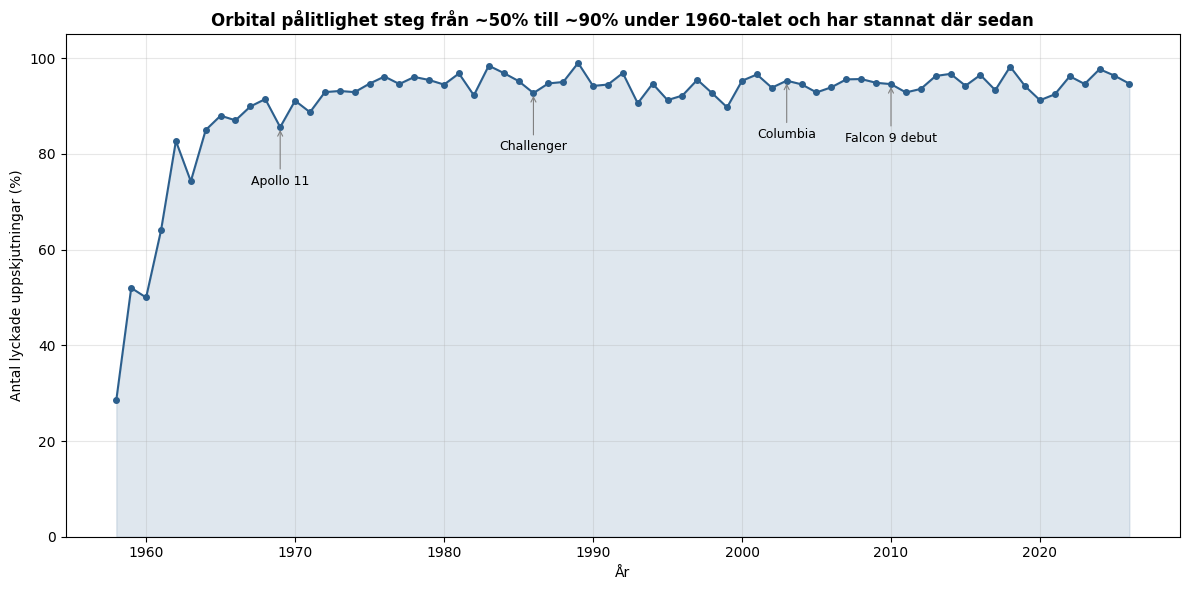

In [17]:
import matplotlib.pyplot as plt

by_year = orbital.groupby("Year").agg(
    total=("Outcome", "count"),
    success=("Outcome", lambda x: (x == "Success").sum())
)
by_year["success_rate"] = by_year["success"] / by_year["total"] * 100

# Filtrera bort år med för lite uppskjutningar så trenden blir mer stabil
min_launches = 5
filtered = by_year[by_year["total"] >= min_launches]

# Plotta
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(filtered.index, filtered["success_rate"], marker="o", markersize=4, linewidth=1.5, color="#2c5f8d")
ax.fill_between(filtered.index, filtered["success_rate"], alpha=0.15, color="#2c5f8d")

# viktiga händelser
events = {
    1969: "Apollo 11",
    1986: "Challenger",
    2003: "Columbia",
    2010: "Falcon 9 debut",
}
for year, label in events.items():
    if year in filtered.index:
        rate = filtered.loc[year, "success_rate"]
        ax.annotate(label, xy=(year, rate), xytext=(year, rate - 12),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
                    fontsize=9, ha="center")

ax.set_xlabel("År")
ax.set_ylabel("Antal lyckade uppskjutningar (%)")
ax.set_title("Orbital pålitlighet steg från ~50% till ~90% under 1960-talet och har stannat där sedan",
             fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

#### Observation

1. Dom första tre åren så misslyckades ungefär varannan raket, och första året så misslyckades ungefär 30 % av uppskjutningarna

2. Man kan se en brant inlärningskurva, från slutet av 50-talet upp till början av 60-talet så har dom ökat pålitligheten extremt.

3. Man kan se att redan på slutet av 60-talet så hade dom uppnått runt 90% pålitlighet.

Jag tycker det är riktigt intressant att trotts 60 år av utveckling så är dom nästan lika pålitliga. Dock så har volymen av uppskjutningar ökat extremt, vilket är vad nästa fråga utforskar.

### 4.2 Hur har volymen av antal uppskjutningar om året ökat det senaste 10 åren?

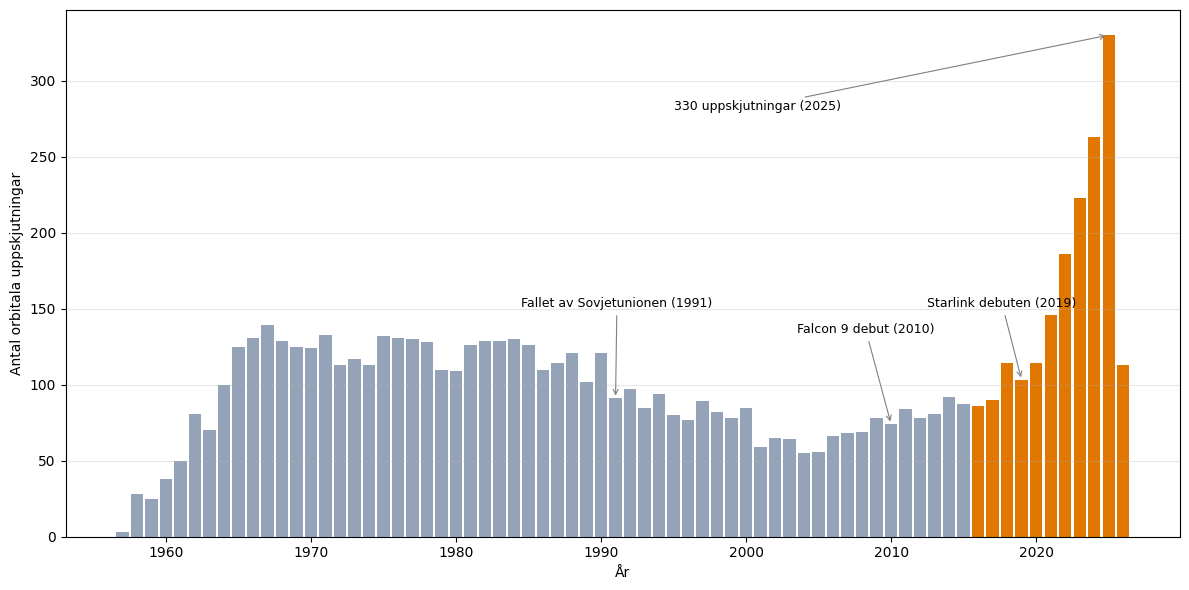

In [33]:
# Jag kan använda mig av by_year dataframen jag skapat till förra diagramet

fig, ax = plt.subplots(figsize=(12, 6))

year_cutoff = 2016

colors = ["#e07700" if year >= year_cutoff else "#94a3b8" for year in by_year.index]
ax.bar(by_year.index, by_year["total"], color=colors, width=0.85)



ax.annotate("Fallet av Sovjetunionen (1991)",
            xy=(1991, by_year.loc[1991, "total"]),
            xytext=(1991 - 6.5, by_year.loc[1991, "total"] + 60),
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
            fontsize=9)

ax.annotate("Falcon 9 debut (2010)",
            xy=(2010, by_year.loc[2010, "total"]),
            xytext=(2010 - 6.5, by_year.loc[2010, "total"] + 60),
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
            fontsize=9)

ax.annotate("Starlink debuten (2019)",
            xy=(2019, by_year.loc[2019, "total"]),
            xytext=(2019 - 6.5, by_year.loc[1991, "total"] + 60),
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
            fontsize=9)

peak_year = by_year["total"].idxmax()
peak_value = by_year["total"].max()
ax.annotate(f"{peak_value} uppskjutningar ({peak_year})",
            xy=(peak_year, peak_value),
            xytext=(peak_year - 30, peak_value * 0.85),
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
            fontsize=9)



ax.set_xlabel("År")
ax.set_ylabel("Antal orbitala uppskjutningar")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

#### Observation

1. Jag visste att raket uppskjutningar hade ökat mycket men inte så här mycket, volymen har ökat nästan 4 gånger dom senaste 10 åren.

2. Även ifall detta inte var frågan så kan jag inte hjälpa att observera att fram tills nu så var det högsta året mot slutet av 60-talet och uppskjutningen har trendat ner ända fram tills mitten av 2000-talet innan man ser en stor ökning igen.

Jag misstänker att spacex är största anledningen för en så stor ökning, det kommer jag kolla på min nästa fråga.

### 4.3 hur stor påverkan har spacex på dessa nummerna?

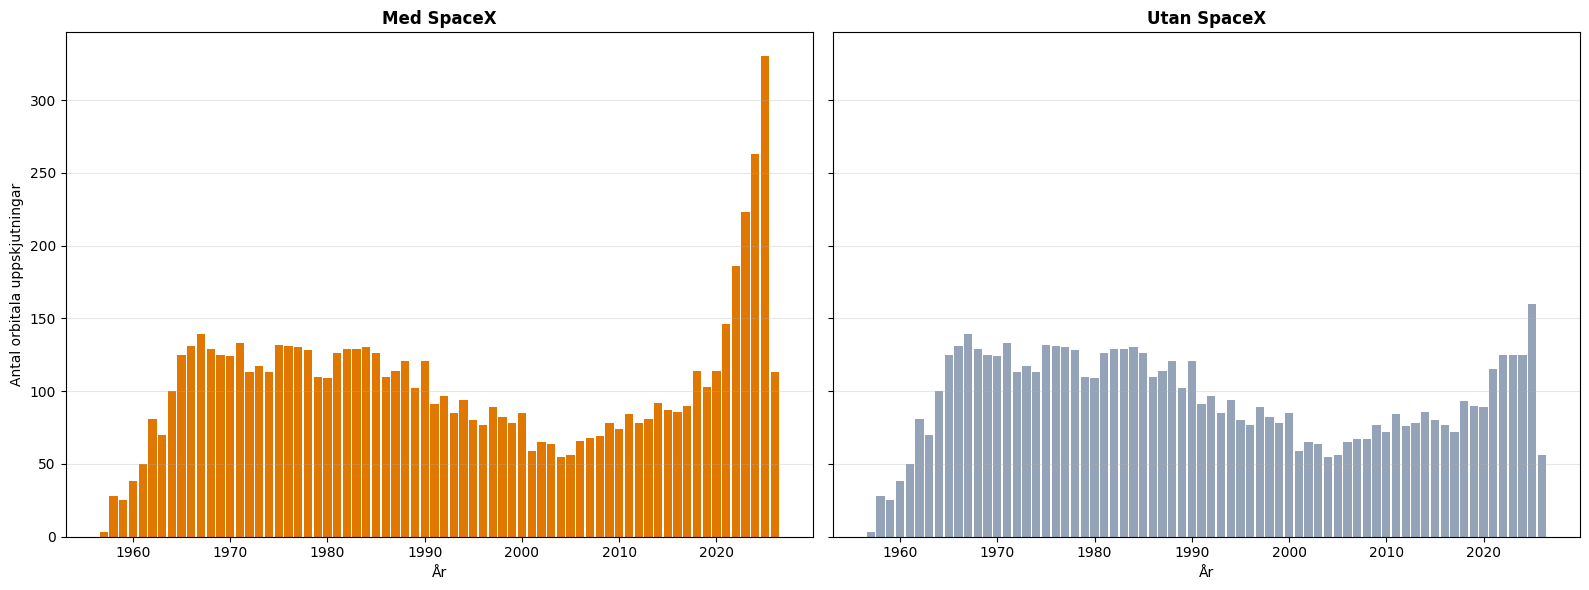

In [19]:
spacex_per_year = orbital[orbital["Agency"] == "SPX"].groupby("Year").size()
total_per_year = orbital.groupby("Year").size()

# Räkna ut utan SpaceX genom att tabort SpaceX från totalen
without_spacex = total_per_year.subtract(spacex_per_year, fill_value=0)

# Skapa två subplots bredvid varandra med samma y axel
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Vänster alla uppskjutningar
ax1.bar(total_per_year.index, total_per_year.values, color="#e07700", width=0.85)
ax1.set_title("Med SpaceX", fontsize=12, fontweight="bold")
ax1.set_xlabel("År")
ax1.set_ylabel("Antal orbitala uppskjutningar")
ax1.grid(True, alpha=0.3, axis="y")

# Höger utan SpaceX
ax2.bar(without_spacex.index, without_spacex.values, color="#94a3b8", width=0.85)
ax2.set_title("Utan SpaceX", fontsize=12, fontweight="bold")
ax2.set_xlabel("År")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

#### Observation

SpaceX spelar en stor roll på ökningen av uppskjutnings frekvens, dom senaste åren så så står dom för omkring hälften av uppskjutningarna.